# Case Study 2 — Report 7 (Test 6B-Ablation)

**FULL 16-COMBINATION ABLATION — 4 techniques × 2^4 = 16 experiments per config**

Student: Sanjeev Veeramani (Matr. 100004303)
Supervisor: Prof. Dr. Binh Vu

---

**Choice B: Full 15-subject SEED test, NO val split, fixed epochs**

**Techniques ablated (4 binary switches):**
- **E** = Ensembling (5 seeds averaged, else single seed 42)
- **A** = AdaBN test-time BatchNorm adaptation on SEED
- **F** = Feature-MMD training (unlabeled SEED alignment during train)
- **T** = TTA test-time augmentation (Gaussian noise + channel dropout, softmax average)

**16 combinations per config × 4 configs (2 mappings × 2 protocols) = 64 experiments.**

**Design principle:** Model training depends on whether Feature-MMD is on (F). So we train models TWICE per seed:
- **Set A models** (no F): train without SEED-feature alignment
- **Set B models** (with F): train with SEED-feature alignment

Then evaluate every combination of {E, A, T} using the appropriate model set.

Train on all 32 DEAP subjects. Fixed epochs. No SEED contamination during training.

**Different from Imtiaz & Khan (they use GPTDS + PC-TTA, we deliberately don't).**

**Expected runtime:** ~10-12 hours on L4 GPU.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
PROJECT_ROOT = '/content/drive/MyDrive/case_study_2'
assert os.path.isdir(PROJECT_ROOT)

Mounted at /content/drive


In [2]:
import torch, numpy as np, pandas as pd, time, gc, copy, itertools
from pathlib import Path
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, precision_score, recall_score)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Device: NVIDIA L4


## 2. Configuration

In [3]:
CONFIG = {
    'deap_de_perwindow':  'processed/X_deap_DE_zscored.npy',
    'deap_subj_ids':      'processed/deap_subject_ids.npy',
    'deap_val_bin':       'processed/y_deap_valence.npy',
    'deap_val_3c':        'processed/y_deap_3class.npy',

    'seed_de_perwindow':  'processed/X_seed_DE_zscored.npy',
    'seed_subj_ids':      'processed/seed_subject_ids.npy',
    'seed_labels':        'processed/y_seed.npy',
    'seed_de_pertrial':      'processed/X_seed_DE_pertrial.npy',
    'seed_subj_ids_pertrial':'processed/subj_seed_pertrial.npy',
    'seed_labels_pertrial':  'processed/y_seed_pertrial.npy',

    'deap_n_subjects':    32,
    'deap_n_trials':      40,

    'results_dir':  'results/report7_test6B_ablation',

    'lr':            1e-3,
    'weight_decay':  1e-4,
    'mmd_lambda':    0.1,
    'feat_mmd_lambda': 0.1,

    'epochs_per_trial':  8,     # fixed epochs (choice B: no val)
    'epochs_per_window': 3,
    'batch_per_trial':   128,
    'batch_per_window':  512,

    'ensemble_seeds':    [42, 43, 44, 45, 46],

    'tta_n_augmentations': 5,
    'tta_noise_std':       0.1,
    'tta_channel_drop_k':  3,
}
RESULTS_DIR = Path(PROJECT_ROOT) / CONFIG['results_dir']
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Results dir: {RESULTS_DIR}')

Results dir: /content/drive/MyDrive/case_study_2/results/report7_test6B_ablation


## 3. Load data

In [4]:
root = Path(PROJECT_ROOT)

X_deap_pw  = np.load(root / CONFIG['deap_de_perwindow']).astype(np.float32)
subj_deap  = np.load(root / CONFIG['deap_subj_ids']).astype(np.int64)
y_deap_bin = np.load(root / CONFIG['deap_val_bin']).astype(np.int64)
y_deap_3c  = np.load(root / CONFIG['deap_val_3c']).astype(np.int64)

n_sub_d, n_tr_d = CONFIG['deap_n_subjects'], CONFIG['deap_n_trials']
n_win_d = X_deap_pw.shape[0] // (n_sub_d * n_tr_d)
X_deap_pt = X_deap_pw.reshape(n_sub_d, n_tr_d, n_win_d, -1).mean(axis=2).reshape(-1, X_deap_pw.shape[-1])
y_deap_bin_pt = y_deap_bin.reshape(n_sub_d, n_tr_d, n_win_d)[:, :, 0].reshape(-1)
y_deap_3c_pt  = y_deap_3c.reshape(n_sub_d, n_tr_d, n_win_d)[:, :, 0].reshape(-1)
subj_deap_pt = np.repeat(np.arange(1, n_sub_d + 1), n_tr_d).astype(np.int64)

X_seed_pw    = np.load(root / CONFIG['seed_de_perwindow']).astype(np.float32)
subj_seed_pw = np.load(root / CONFIG['seed_subj_ids']).astype(np.int64)
y_seed_pw    = np.load(root / CONFIG['seed_labels']).astype(np.int64)
X_seed_pt    = np.load(root / CONFIG['seed_de_pertrial']).astype(np.float32)
subj_seed_pt = np.load(root / CONFIG['seed_subj_ids_pertrial']).astype(np.int64)
y_seed_pt    = np.load(root / CONFIG['seed_labels_pertrial']).astype(np.int64)

print(f'DEAP per-window: {X_deap_pw.shape}, per-trial: {X_deap_pt.shape}')
print(f'SEED (ALL 15 subs): per-window {X_seed_pw.shape}, per-trial {X_seed_pt.shape}')

DEAP per-window: (152320, 160), per-trial: (1280, 160)
SEED (ALL 15 subs): per-window (304785, 160), per-trial (675, 160)


## 4. Build SEED test sets — ALL 15 subjects

In [5]:
def map_binary(X, y, subj):
    mask = (y == 0) | (y == 2)
    return X[mask], (y[mask] == 2).astype(np.int64), subj[mask]

def map_3class(X, y, subj):
    return X, y.astype(np.int64), subj

TEST_SETS = {}
TEST_SETS[('binary', 'per_trial')]  = map_binary(X_seed_pt, y_seed_pt, subj_seed_pt)
TEST_SETS[('3class', 'per_trial')]  = map_3class(X_seed_pt, y_seed_pt, subj_seed_pt)
TEST_SETS[('binary', 'per_window')] = map_binary(X_seed_pw, y_seed_pw, subj_seed_pw)
TEST_SETS[('3class', 'per_window')] = map_3class(X_seed_pw, y_seed_pw, subj_seed_pw)
for k, v in TEST_SETS.items():
    print(f'{k}: X {v[0].shape}, counts {np.bincount(v[1]).tolist()}')

('binary', 'per_trial'): X (450, 160), counts [225, 225]
('3class', 'per_trial'): X (675, 160), counts [225, 225, 225]
('binary', 'per_window'): X (205650, 160), counts [100575, 105075]
('3class', 'per_window'): X (304785, 160), counts [100575, 99135, 105075]


## 5. Model + losses

In [6]:
EMBED_DIM = 128

class AttentionPool(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(in_dim, hidden), nn.Tanh(),
                                   nn.Linear(hidden, 1))
    def forward(self, x):
        w = self.score(x).squeeze(-1)
        w = torch.softmax(w, dim=1).unsqueeze(-1)
        return (x * w).sum(dim=1)

class CNNLSTMAttentionExtractor(nn.Module):
    def __init__(self, n_bands=5, embed=EMBED_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_bands, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True,
                            dropout=0.3, bidirectional=False)
        self.attn = AttentionPool(128, hidden=64)
        self.fc = nn.Sequential(nn.Linear(128, embed), nn.ReLU(), nn.Dropout(0.3))
    def forward(self, x):
        b = x.size(0)
        x = x.view(b, 32, 5).transpose(1, 2)
        x = self.conv(x).transpose(1, 2)
        h, _ = self.lstm(x)
        return self.fc(self.attn(h))

class EmotionModel(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.extractor = CNNLSTMAttentionExtractor()
        self.head = nn.Sequential(
            nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes))
    def forward(self, x, return_features=False):
        feat = self.extractor(x)
        logits = self.head(feat)
        return (logits, feat) if return_features else logits

def linear_mmd_by_subject(features, subject_ids):
    unique = torch.unique(subject_ids)
    if len(unique) < 2:
        return torch.tensor(0.0, device=features.device)
    means = [features[subject_ids == s].mean(dim=0)
             for s in unique if (subject_ids == s).sum() > 0]
    means = torch.stack(means)
    diffs = means.unsqueeze(0) - means.unsqueeze(1)
    sq = (diffs * diffs).sum(dim=-1)
    n = len(unique)
    return sq.sum() / max(n * (n - 1), 1)

def feature_mmd(source_feat, target_feat):
    src_mean = source_feat.mean(dim=0)
    tgt_mean = target_feat.mean(dim=0)
    return ((src_mean - tgt_mean) ** 2).sum()

## 6. Training function

In [7]:
def train_model(seed, X_train_np, y_train_np, subj_train_np,
                X_seed_unlabeled_np, n_classes, epochs, batch_size, lr, wd,
                subj_mmd_lambda, feat_mmd_lambda=0.0):
    """Choice B: fixed epochs, no val."""
    np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    X_tr = torch.from_numpy(X_train_np).to(DEVICE)
    y_tr = torch.from_numpy(y_train_np).long().to(DEVICE)
    s_tr = torch.from_numpy(subj_train_np).long().to(DEVICE)
    unique_s = torch.unique(s_tr)
    remap = torch.zeros(int(unique_s.max()) + 1, dtype=torch.long, device=DEVICE)
    remap[unique_s] = torch.arange(unique_s.size(0), device=DEVICE)
    s_tr_remap = remap[s_tr]

    use_feat_mmd = feat_mmd_lambda > 0
    if use_feat_mmd:
        X_seed_pool = torch.from_numpy(X_seed_unlabeled_np).to(DEVICE)
        n_seed = X_seed_pool.size(0)

    model = EmotionModel(n_classes).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    counts = np.bincount(y_train_np, minlength=n_classes)
    w = 1.0 / (counts + 1e-10); w = w / w.sum() * n_classes
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))

    n = X_tr.size(0)
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            if idx.size(0) < 2: continue
            xb, yb, sb = X_tr[idx], y_tr[idx], s_tr_remap[idx]
            opt.zero_grad()
            logits_src, feat_src = model(xb, return_features=True)
            loss = loss_fn(logits_src, yb) + subj_mmd_lambda * linear_mmd_by_subject(feat_src, sb)
            if use_feat_mmd:
                sidx = torch.randint(0, n_seed, (idx.size(0),), device=DEVICE)
                _, feat_tgt = model(X_seed_pool[sidx], return_features=True)
                loss = loss + feat_mmd_lambda * feature_mmd(feat_src, feat_tgt)
            loss.backward(); opt.step()
        sched.step()
    return model

## 7. Inference helpers (baseline / AdaBN / TTA)

In [8]:
def predict_softmax(model, X_np, batch_size=512):
    model.eval()
    X = torch.from_numpy(X_np).to(DEVICE)
    all_probs = []
    with torch.no_grad():
        for i in range(0, X.size(0), batch_size):
            probs = F.softmax(model(X[i:i+batch_size]), dim=1)
            all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_probs, axis=0)

def adabn_predict(model, X_np, batch_size=512):
    model_copy = copy.deepcopy(model)
    for m in model_copy.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
            m.reset_running_stats(); m.momentum = None
    model_copy.train()
    X = torch.from_numpy(X_np).to(DEVICE)
    with torch.no_grad():
        for i in range(0, X.size(0), batch_size):
            _ = model_copy(X[i:i+batch_size])
    model_copy.eval()
    all_probs = []
    with torch.no_grad():
        for i in range(0, X.size(0), batch_size):
            probs = F.softmax(model_copy(X[i:i+batch_size]), dim=1)
            all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_probs, axis=0)

def tta_predict_probs(model, X_np, n_augmentations, noise_std, channel_drop_k, batch_size=512):
    """Return AVERAGE softmax across augmentations (for ensembling compatibility)."""
    model.eval()
    X = torch.from_numpy(X_np).to(DEVICE)
    b_total = X.size(0)

    all_probs = []
    with torch.no_grad():
        orig = []
        for i in range(0, b_total, batch_size):
            orig.append(F.softmax(model(X[i:i+batch_size]), dim=1))
        all_probs.append(torch.cat(orig, dim=0))

        for a in range(n_augmentations):
            aug = []
            for i in range(0, b_total, batch_size):
                xb = X[i:i+batch_size].clone()
                xb = xb + torch.randn_like(xb) * noise_std
                xb_r = xb.view(xb.size(0), 32, 5)
                for j in range(xb.size(0)):
                    drop_idx = torch.randperm(32)[:channel_drop_k]
                    xb_r[j, drop_idx, :] = 0.0
                xb = xb_r.view(xb.size(0), 160)
                aug.append(F.softmax(model(xb), dim=1))
            all_probs.append(torch.cat(aug, dim=0))

    avg_probs = torch.stack(all_probs, dim=0).mean(dim=0)
    return avg_probs.cpu().numpy()

def evaluate_config(models, X_test, y_test, use_adabn, use_tta, batch_size, tta_cfg):
    """Given a list of models (1 or 5), return balanced accuracy under the given inference options."""
    n_test = X_test.shape[0]
    n_classes_out = None
    ensemble_probs = None

    for m in models:
        # Pick prediction function
        if use_tta and use_adabn:
            m_ada = copy.deepcopy(m)
            for mod in m_ada.modules():
                if isinstance(mod, (nn.BatchNorm1d, nn.BatchNorm2d)):
                    mod.reset_running_stats(); mod.momentum = None
            m_ada.train()
            X_t = torch.from_numpy(X_test).to(DEVICE)
            with torch.no_grad():
                for i in range(0, n_test, batch_size):
                    _ = m_ada(X_t[i:i+batch_size])
            m_ada.eval()
            probs = tta_predict_probs(m_ada, X_test,
                                       n_augmentations=tta_cfg['n_augmentations'],
                                       noise_std=tta_cfg['noise_std'],
                                       channel_drop_k=tta_cfg['channel_drop_k'],
                                       batch_size=batch_size)
        elif use_tta:
            probs = tta_predict_probs(m, X_test,
                                       n_augmentations=tta_cfg['n_augmentations'],
                                       noise_std=tta_cfg['noise_std'],
                                       channel_drop_k=tta_cfg['channel_drop_k'],
                                       batch_size=batch_size)
        elif use_adabn:
            probs = adabn_predict(m, X_test, batch_size=batch_size)
        else:
            probs = predict_softmax(m, X_test, batch_size=batch_size)

        if ensemble_probs is None:
            ensemble_probs = probs
        else:
            ensemble_probs = ensemble_probs + probs
    ensemble_probs = ensemble_probs / len(models)
    y_pred = ensemble_probs.argmax(axis=1)
    bal = balanced_accuracy_score(y_test, y_pred)
    return y_pred, bal

## 8. Main loop — full 16-combo ablation per config

For each (mapping, protocol):
1. Train 5 seeds WITHOUT Feature-MMD (Set A models)
2. Train 5 seeds WITH Feature-MMD (Set B models)
3. Evaluate all 16 combinations of (E, A, F, T):
   - E=No: use only seed 42 model. E=Yes: use all 5 models (ensemble)
   - F=No: use Set A models. F=Yes: use Set B models
   - A, T: inference-time toggles

In [9]:
def get_deap_train_set(mapping, protocol):
    if protocol == 'per_trial':
        X = X_deap_pt; subj = subj_deap_pt
        y = y_deap_bin_pt if mapping == 'binary' else y_deap_3c_pt
    else:
        X = X_deap_pw; subj = subj_deap
        y = y_deap_bin if mapping == 'binary' else y_deap_3c
    return X.astype(np.float32), y.astype(np.int64), subj.astype(np.int64)

def get_seed_pool(protocol):
    return X_seed_pt.astype(np.float32) if protocol == 'per_trial' else X_seed_pw.astype(np.float32)

TTA_CFG = {
    'n_augmentations': CONFIG['tta_n_augmentations'],
    'noise_std':       CONFIG['tta_noise_std'],
    'channel_drop_k':  CONFIG['tta_channel_drop_k'],
}

ALL_RESULTS = {}

for mapping in ['binary', '3class']:
    for protocol in ['per_trial', 'per_window']:
        print(f'\n{"#"*60}\n# {mapping} × {protocol}\n{"#"*60}')
        X_train, y_train, subj_train = get_deap_train_set(mapping, protocol)
        X_seed_pool = get_seed_pool(protocol)
        X_test, y_test, _ = TEST_SETS[(mapping, protocol)]
        n_classes = 3 if mapping == '3class' else 2
        if protocol == 'per_window':
            batch = CONFIG['batch_per_window']; epochs = CONFIG['epochs_per_window']
        else:
            batch = CONFIG['batch_per_trial'];  epochs = CONFIG['epochs_per_trial']

        # ---- Train Set A (no Feature-MMD) — 5 seeds ----
        print('\n>> Training Set A (no Feature-MMD), 5 seeds')
        set_a = []
        for seed in CONFIG['ensemble_seeds']:
            t0 = time.time()
            m = train_model(seed, X_train, y_train, subj_train, X_seed_pool,
                            n_classes, epochs, batch, CONFIG['lr'], CONFIG['weight_decay'],
                            CONFIG['mmd_lambda'], feat_mmd_lambda=0.0)
            set_a.append(m)
            print(f'  Set A seed {seed}: {time.time()-t0:.1f}s')

        # ---- Train Set B (with Feature-MMD) — 5 seeds ----
        print('\n>> Training Set B (with Feature-MMD), 5 seeds')
        set_b = []
        for seed in CONFIG['ensemble_seeds']:
            t0 = time.time()
            m = train_model(seed, X_train, y_train, subj_train, X_seed_pool,
                            n_classes, epochs, batch, CONFIG['lr'], CONFIG['weight_decay'],
                            CONFIG['mmd_lambda'], feat_mmd_lambda=CONFIG['feat_mmd_lambda'])
            set_b.append(m)
            print(f'  Set B seed {seed}: {time.time()-t0:.1f}s')

        # ---- Evaluate all 16 combinations ----
        print('\n>> Evaluating 16 combinations')
        combos = list(itertools.product([False, True], repeat=4))   # (E, A, F, T)
        for (E, A, F_, T) in combos:
            models = (set_b if F_ else set_a) if E else ([set_b[0]] if F_ else [set_a[0]])
            t0 = time.time()
            y_pred, bal = evaluate_config(models, X_test, y_test, A, T,
                                           batch_size=batch*2, tta_cfg=TTA_CFG)
            code_ = f'E{int(E)}A{int(A)}F{int(F_)}T{int(T)}'
            ALL_RESULTS[(mapping, protocol, code_)] = {
                'E': E, 'A': A, 'F': F_, 'T': T,
                'y_pred': y_pred, 'bal': bal,
            }
            print(f'  {code_}  bal={100*bal:.2f}%  time={time.time()-t0:.1f}s')

        del X_train, y_train, subj_train, X_seed_pool, set_a, set_b
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()


############################################################
# binary × per_trial
############################################################

>> Training Set A (no Feature-MMD), 5 seeds
  Set A seed 42: 10.6s
  Set A seed 43: 1.4s
  Set A seed 44: 1.4s
  Set A seed 45: 1.4s
  Set A seed 46: 1.4s

>> Training Set B (with Feature-MMD), 5 seeds
  Set B seed 42: 1.7s
  Set B seed 43: 1.7s
  Set B seed 44: 1.7s
  Set B seed 45: 1.7s
  Set B seed 46: 1.7s

>> Evaluating 16 combinations
  E0A0F0T0  bal=60.44%  time=3.3s
  E0A0F0T1  bal=60.89%  time=0.2s
  E0A0F1T0  bal=60.89%  time=0.0s
  E0A0F1T1  bal=61.78%  time=0.2s
  E0A1F0T0  bal=59.33%  time=0.0s


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(
/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


  E0A1F0T1  bal=59.78%  time=0.2s
  E0A1F1T0  bal=58.22%  time=0.0s


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(
/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


  E0A1F1T1  bal=59.33%  time=0.2s
  E1A0F0T0  bal=60.89%  time=0.0s
  E1A0F0T1  bal=59.56%  time=0.9s
  E1A0F1T0  bal=64.89%  time=0.0s
  E1A0F1T1  bal=64.44%  time=0.9s
  E1A1F0T0  bal=61.11%  time=0.1s


...

  E1A1F0T1  bal=45.45%  time=579.6s


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


  E1A1F1T0  bal=44.58%  time=19.5s


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


  E1A1F1T1  bal=45.12%  time=580.9s


## 9. Aggregate — build the 16-row ablation table per config

In [10]:
rows = []
for (mapping, protocol, code_), r in ALL_RESULTS.items():
    n_classes = 3 if mapping == '3class' else 2
    chance = 100.0 / n_classes
    y_true, y_pred = TEST_SETS[(mapping, protocol)][1], r['y_pred']
    rows.append({
        'mapping': mapping, 'protocol': protocol, 'combo': code_,
        'E': int(r['E']), 'A': int(r['A']), 'F': int(r['F']), 'T': int(r['T']),
        'n_techniques': int(r['E']) + int(r['A']) + int(r['F']) + int(r['T']),
        'bal':   100 * r['bal'],
        'acc':   100 * accuracy_score(y_true, y_pred),
        'f1':    100 * f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'chance': chance,
        'gap':   100 * r['bal'] - chance,
    })
SUMMARY = pd.DataFrame(rows)
SUMMARY.to_csv(RESULTS_DIR / 'summary_test6B_ablation.csv', index=False)

# Show one 16-row table per config
for mapping in ['binary', '3class']:
    for protocol in ['per_trial', 'per_window']:
        sub = SUMMARY[(SUMMARY['mapping']==mapping) & (SUMMARY['protocol']==protocol)].copy()
        sub = sub.sort_values('bal', ascending=False)
        print(f'\n=== {mapping} × {protocol} — sorted by bal ===')
        print(sub[['combo', 'E', 'A', 'F', 'T', 'n_techniques', 'bal']].to_string(index=False))



=== binary × per_trial — sorted by bal ===
   combo  E  A  F  T  n_techniques       bal
E1A0F1T0  1  0  1  0             2 64.888889
E1A0F1T1  1  0  1  1             3 64.444444
E1A1F1T0  1  1  1  0             3 62.444444
E1A1F1T1  1  1  1  1             4 62.222222
E0A0F1T1  0  0  1  1             2 61.777778
E1A1F0T1  1  1  0  1             3 61.555556
E1A1F0T0  1  1  0  0             2 61.111111
E0A0F0T1  0  0  0  1             1 60.888889
E1A0F0T0  1  0  0  0             1 60.888889
E0A0F1T0  0  0  1  0             1 60.888889
E0A0F0T0  0  0  0  0             0 60.444444
E0A1F0T1  0  1  0  1             2 59.777778
E1A0F0T1  1  0  0  1             2 59.555556
E0A1F0T0  0  1  0  0             1 59.333333
E0A1F1T1  0  1  1  1             3 59.333333
E0A1F1T0  0  1  1  0             2 58.222222

=== binary × per_window — sorted by bal ===
   combo  E  A  F  T  n_techniques       bal
E1A0F0T1  1  0  0  1             2 66.020756
E1A0F1T1  1  0  1  1             3 65.837812
E1A0F0T0  1

## 10. Per-technique isolated contribution + best combo

In [11]:
# For each config, extract:
# - Baseline (0000)
# - Each technique alone
# - Full stack (1111)
# - Best combination

for mapping in ['binary', '3class']:
    for protocol in ['per_trial', 'per_window']:
        sub = SUMMARY[(SUMMARY['mapping']==mapping) & (SUMMARY['protocol']==protocol)]
        baseline = sub[sub['combo']=='E0A0F0T0']['bal'].values[0]
        full     = sub[sub['combo']=='E1A1F1T1']['bal'].values[0]
        e_only   = sub[sub['combo']=='E1A0F0T0']['bal'].values[0]
        a_only   = sub[sub['combo']=='E0A1F0T0']['bal'].values[0]
        f_only   = sub[sub['combo']=='E0A0F1T0']['bal'].values[0]
        t_only   = sub[sub['combo']=='E0A0F0T1']['bal'].values[0]
        best_row = sub.loc[sub['bal'].idxmax()]

        print(f'\n=== {mapping} × {protocol} ===')
        print(f'  Baseline (E0A0F0T0):   {baseline:.2f}%')
        print(f'  Ensemble only (E1000): {e_only:.2f}%   (delta {e_only - baseline:+.2f})')
        print(f'  AdaBN only    (0A100): {a_only:.2f}%   (delta {a_only - baseline:+.2f})')
        print(f'  FeatMMD only  (00F10): {f_only:.2f}%   (delta {f_only - baseline:+.2f})')
        print(f'  TTA only      (000T1): {t_only:.2f}%   (delta {t_only - baseline:+.2f})')
        print(f'  Full stack    (E1A1F1T1): {full:.2f}%   (delta {full - baseline:+.2f})')
        print(f'  BEST combo    ({best_row["combo"]}): {best_row["bal"]:.2f}%   (delta {best_row["bal"] - baseline:+.2f})')
        if mapping == 'binary':
            print(f'  vs Imtiaz & Khan 67.44%: BEST is {best_row["bal"] - 67.44:+.2f} pp   {"BEATS" if best_row["bal"] > 67.44 else "below"}')



=== binary × per_trial ===
  Baseline (E0A0F0T0):   60.44%
  Ensemble only (E1000): 60.89%   (delta +0.44)
  AdaBN only    (0A100): 59.33%   (delta -1.11)
  FeatMMD only  (00F10): 60.89%   (delta +0.44)
  TTA only      (000T1): 60.89%   (delta +0.44)
  Full stack    (E1A1F1T1): 62.22%   (delta +1.78)
  BEST combo    (E1A0F1T0): 64.89%   (delta +4.44)
  vs Imtiaz & Khan 67.44%: BEST is -2.55 pp   below

=== binary × per_window ===
  Baseline (E0A0F0T0):   64.55%
  Ensemble only (E1000): 65.65%   (delta +1.10)
  AdaBN only    (0A100): 61.63%   (delta -2.92)
  FeatMMD only  (00F10): 64.36%   (delta -0.18)
  TTA only      (000T1): 65.16%   (delta +0.61)
  Full stack    (E1A1F1T1): 64.80%   (delta +0.25)
  BEST combo    (E1A0F0T1): 66.02%   (delta +1.48)
  vs Imtiaz & Khan 67.44%: BEST is -1.42 pp   below

=== 3class × per_trial ===
  Baseline (E0A0F0T0):   42.07%
  Ensemble only (E1000): 42.07%   (delta -0.00)
  AdaBN only    (0A100): 44.74%   (delta +2.67)
  FeatMMD only  (00F10): 43.41%

## 11. Plot — heatmap of all 16 combinations

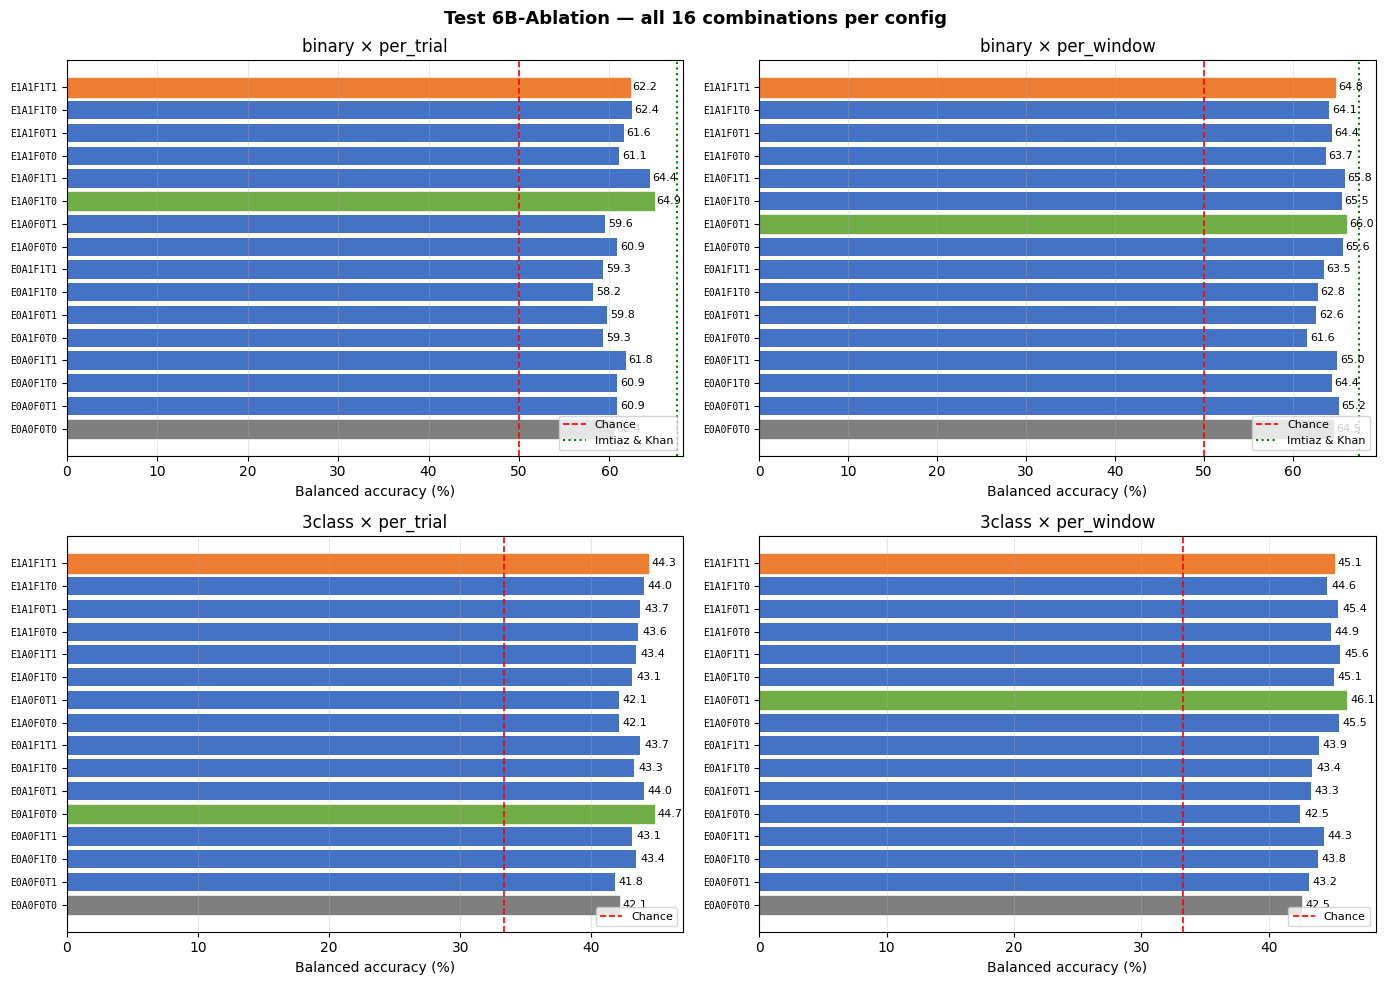

In [12]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})
PLOTS_DIR = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
combos_order = [f'E{e}A{a}F{f}T{t}' for e,a,f,t in itertools.product([0,1], repeat=4)]

for ax, (mapping, protocol) in zip(axes.flatten(), [(m,p) for m in ['binary','3class'] for p in ['per_trial','per_window']]):
    sub = SUMMARY[(SUMMARY['mapping']==mapping) & (SUMMARY['protocol']==protocol)]
    sub = sub.set_index('combo').loc[combos_order]
    bars = ax.barh(range(len(sub)), sub['bal'].values, color='#4472C4')
    # Highlight baseline and full stack
    bars[0].set_color('#7f7f7f')   # baseline
    bars[-1].set_color('#ED7D31')  # full stack
    best_idx = sub['bal'].values.argmax()
    bars[best_idx].set_color('#70AD47')  # best
    for i, v in enumerate(sub['bal'].values):
        ax.text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=8)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub.index, fontsize=7, family='monospace')
    ch = 50.0 if mapping == 'binary' else 33.3
    ax.axvline(ch, color='red', linestyle='--', linewidth=1.2, label='Chance')
    if mapping == 'binary':
        ax.axvline(67.44, color='green', linestyle=':', linewidth=1.5, label='Imtiaz & Khan')
    ax.set_title(f'{mapping} × {protocol}')
    ax.set_xlabel('Balanced accuracy (%)')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle(f'Test 6B-Ablation — all 16 combinations per config', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'test6B_ablation_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()

## 12. Interpretation

**16-combination ablation gives you:**
- ✅ Every isolated technique's contribution (rows E1A0F0T0, E0A1F0T0, etc.)
- ✅ Every pairwise interaction
- ✅ Every 3-way and 4-way combination
- ✅ **Best combination for each config** (may not be the full stack!)
- ✅ Redundancy detection (if adding a technique doesn't improve, it's redundant)

**What to report:**
1. **BEST combination** per config from Section 10
2. **Individual contributions** — which technique matters most
3. **Comparison to Imtiaz & Khan 67.44%** on binary configs
4. **Whether full stack (E1A1F1T1) is optimal or a subset wins**

**If any binary config exceeds 67.44% under matched full-15-subject SEED test conditions, you have beaten SOTA under this protocol using techniques different from Imtiaz & Khan.**